<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/student_score_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Student Score Prediction using Machine Learning

dataset : https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

Data Loading

In [ ]:
df=pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.info()
print(f'Shape of the dataset:{df.shape}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Data Inspection

In [ ]:
print("Missing values:\n")
print(df.isnull().sum())

df.duplicated().sum()
print("\nNumber of duplicate rows:",df.duplicated().sum())

Missing values:

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Number of duplicate rows: 0


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67
Hours_Studied,0
Access_to_Resources,0
Parental_Involvement,0
Attendance,0
Extracurricular_Activities,0
Motivation_Level,0
Internet_Access,0


In [ ]:
print(f'Exam_Score Categories:{df.Exam_Score.unique()}')


Exam_Score Categories:[ 67  61  74  71  70  66  69  72  68  65  64  60  63  62 100  76  79  73
  78  89  75  59  86  97  83  84  80  58  94  55  92  82  77 101  88  91
  99  87  57  96  98  95  85  93  56]


Exploratory Data Analysis

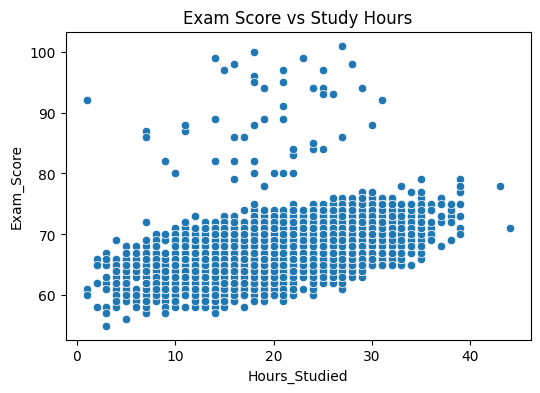

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Exam Score vs Study Hours")
plt.show()

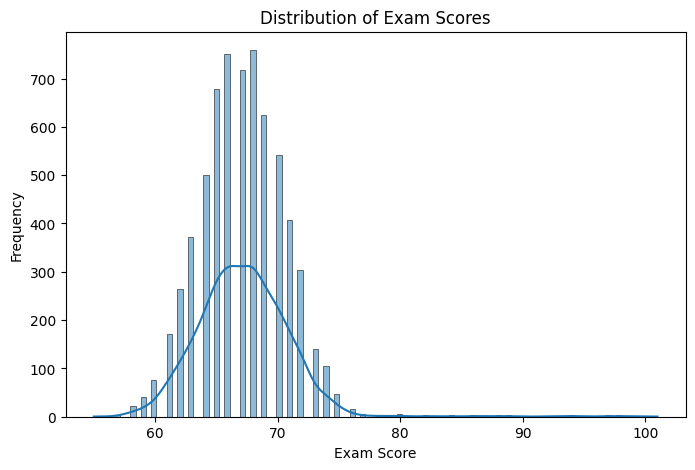

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

Correlation Heatmap

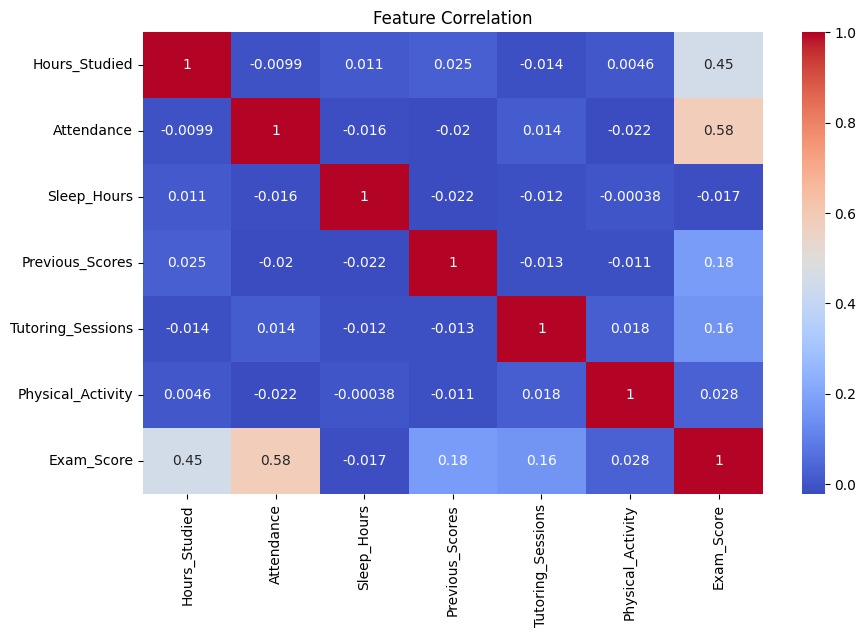

In [ ]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


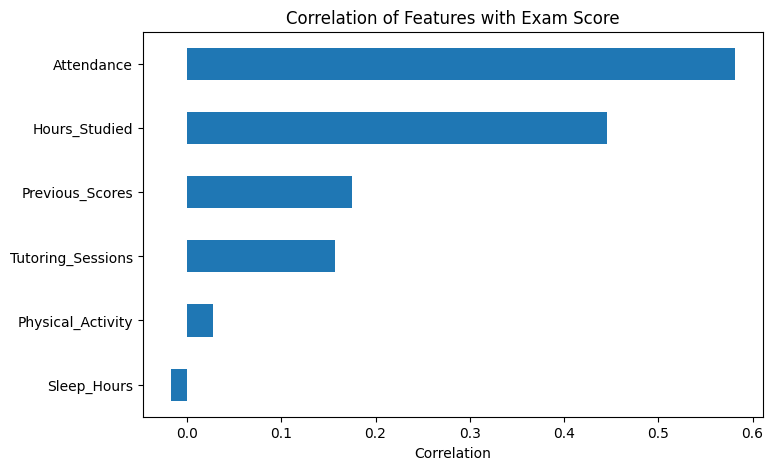

In [ ]:
target_corr = corr_matrix["Exam_Score"].drop("Exam_Score").sort_values()

plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh")
plt.title("Correlation of Features with Exam Score")
plt.xlabel("Correlation")
plt.show()

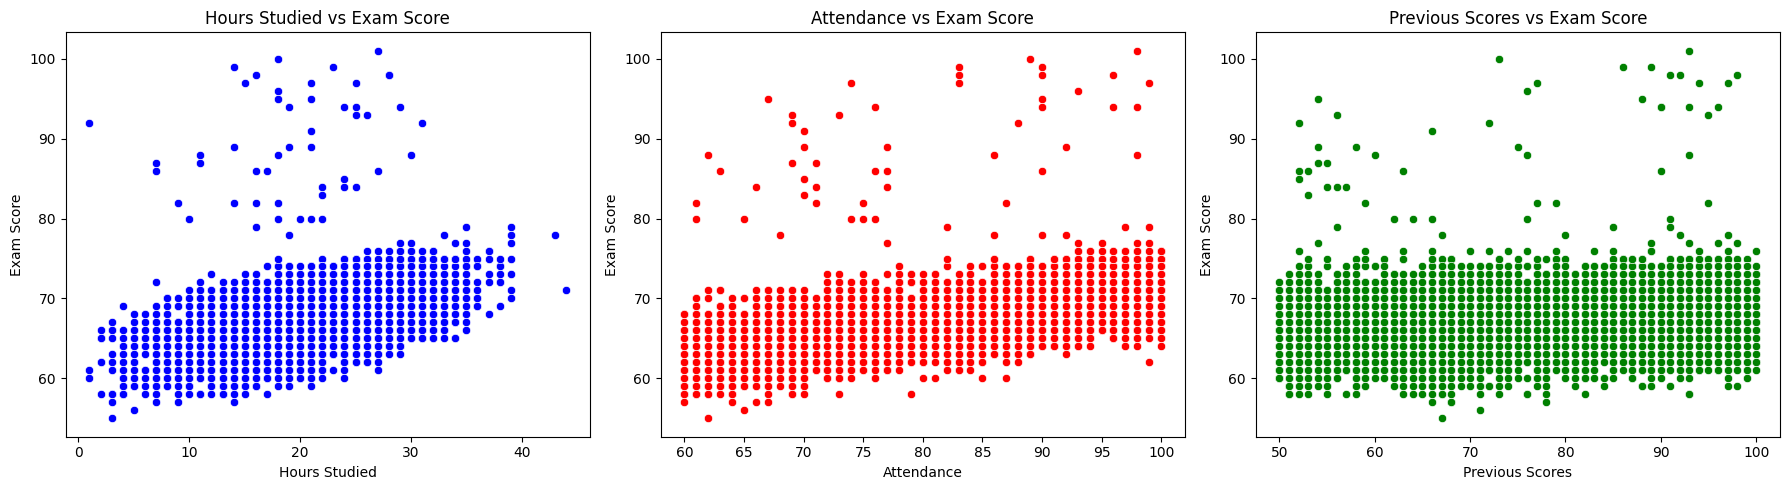

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hours_Studied vs Exam_Score
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, ax=axes[0], color='blue')
axes[0].set_title('Hours Studied vs Exam Score')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Exam Score')

# Plot 2: Attendance vs Exam_Score
sns.scatterplot(x='Attendance', y='Exam_Score', data=df, ax=axes[1], color='red')
axes[1].set_title('Attendance vs Exam Score')
axes[1].set_xlabel('Attendance')
axes[1].set_ylabel('Exam Score')

# Plot 3: Previous_Scores vs Exam_Score
sns.scatterplot(x='Previous_Scores', y='Exam_Score', data=df, ax=axes[2], color='green')
axes[2].set_title('Previous Scores vs Exam Score')
axes[2].set_xlabel('Previous Scores')
axes[2].set_ylabel('Exam Score')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Feature preparation

In [ ]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


Linear Regression Performance
MAE: 0.45028541547009376
RMSE: 1.8046317813990214
R²: 0.7696017567194432


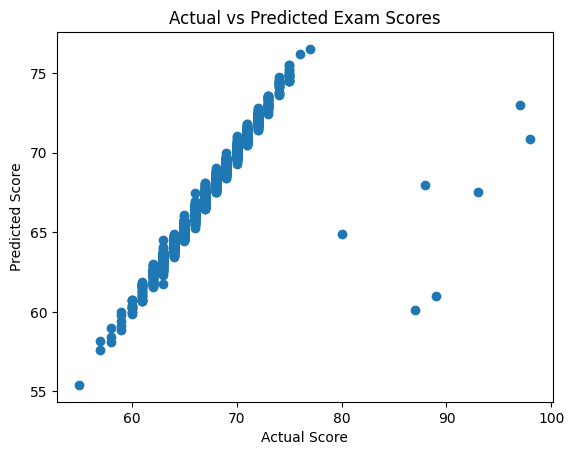

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()



Polynomial Regression

In [ ]:

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial R²:", poly_r2)


Polynomial R²: 0.7473427195932745


Ridge

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge R²:", ridge_r2)

Ridge R²: 0.7696283631925654


Lasso

In [ ]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso R²:", lasso_r2)

Lasso R²: 0.7067184091022684


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Polynomial"],
    "R2 Score": [r2, ridge_r2, lasso_r2, poly_r2]
})

print(results)

        Model  R2 Score
0      Linear  0.769602
1       Ridge  0.769628
2       Lasso  0.706718
3  Polynomial  0.747343


The Ridge regression model performed the best for predicting student exam scores, achieving the highest R² score among all the models tested.